# Customer Churn Prediction

This project analyzes customer churn using the Telco Customer Churn dataset.

The goal is to understand which customer characteristics are associated with churn and to build machine learning models that can predict whether a customer is likely to leave the company.

Two classification models are compared:
- Decision Tree Classifier
- Logistic Regression

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

In [2]:
df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
print("Dataset Shape:", df.shape)

print("\nDataset Information:")
df.info()

Dataset Shape: (7043, 21)

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 

In [4]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [5]:
df['TotalCharges'] = pd.to_numeric(
    df['TotalCharges'],
    errors='coerce'
)

In [6]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [7]:
df['TotalCharges'] = df['TotalCharges'].fillna(
    df['TotalCharges'].median()
)

In [8]:
print(df['Churn'].value_counts())

print("\nChurn Percentage:")
print(df['Churn'].value_counts(normalize=True) * 100)

Churn
No     5174
Yes    1869
Name: count, dtype: int64

Churn Percentage:
Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64


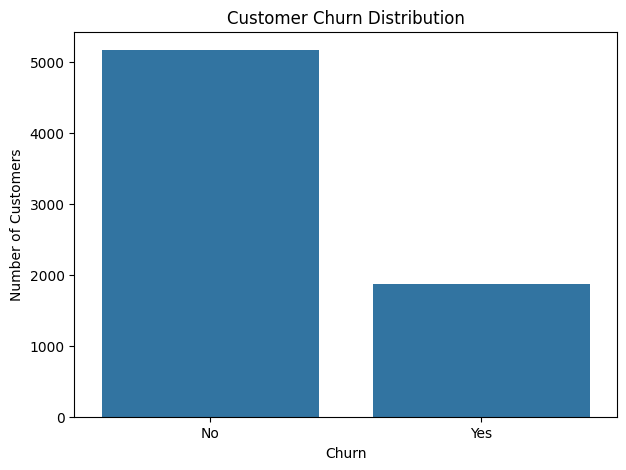

In [9]:
plt.figure(figsize=(7, 5))

sns.countplot(data=df, x='Churn')

plt.title('Customer Churn Distribution')
plt.xlabel('Churn')
plt.ylabel('Number of Customers')

plt.show()

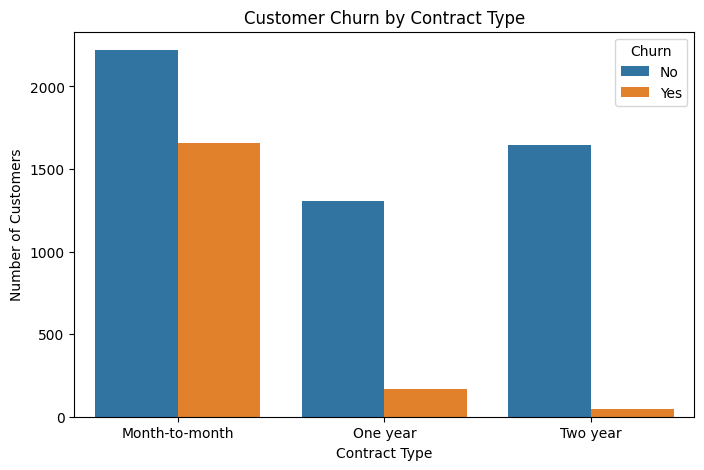

In [10]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x='Contract',
    hue='Churn'
)

plt.title('Customer Churn by Contract Type')
plt.xlabel('Contract Type')
plt.ylabel('Number of Customers')

plt.show()

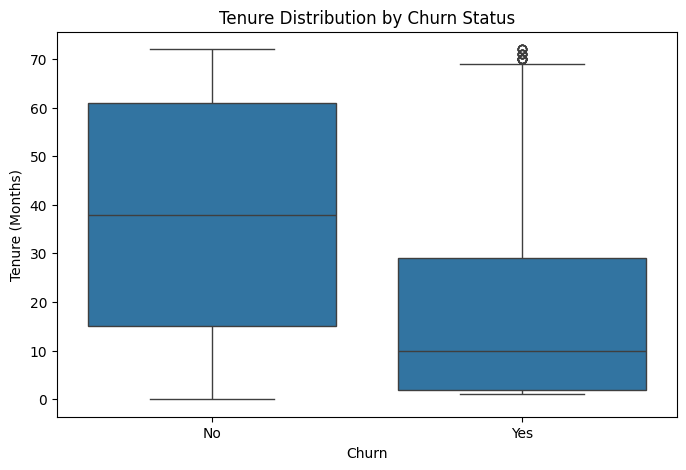

In [11]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x='Churn',
    y='tenure'
)

plt.title('Tenure Distribution by Churn Status')
plt.xlabel('Churn')
plt.ylabel('Tenure (Months)')

plt.show()

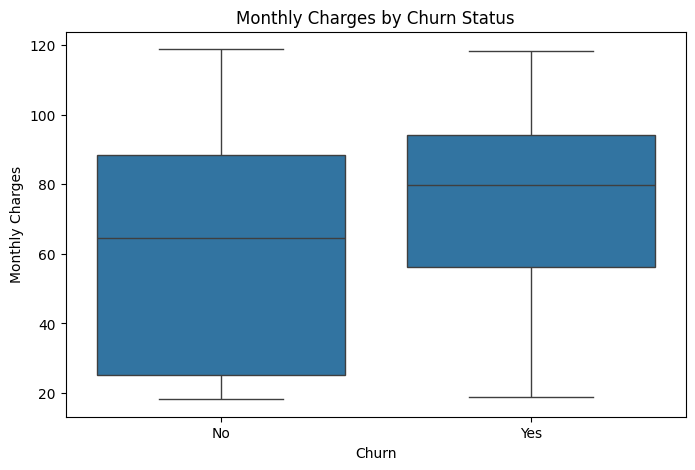

In [12]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x='Churn',
    y='MonthlyCharges'
)

plt.title('Monthly Charges by Churn Status')
plt.xlabel('Churn')
plt.ylabel('Monthly Charges')

plt.show()

## Exploratory Data Analysis Summary

The EDA shows that customer churn is not evenly distributed across all customer groups. Customers with month-to-month contracts appear more likely to churn compared with customers on one-year or two-year contracts. Customers with shorter tenure also show a higher likelihood of leaving the company. Monthly charges may also be associated with churn, with some customers paying higher monthly charges showing increased churn risk. These patterns suggest that contract type, tenure, and monthly charges may be important factors in predicting customer churn.

## Class Imbalance

The churn target variable contains two classes: customers who stayed and customers who churned. The number of customers who stayed is larger than the number of customers who churned, indicating some class imbalance. This is important because a model could achieve high accuracy by mainly predicting the majority class. Therefore, accuracy should not be the only evaluation metric, and precision, recall, and F1-score should also be considered.

In [13]:
df = df.drop(columns=['customerID'])

In [14]:
df['Churn'] = df['Churn'].map({
    'Yes': 1,
    'No': 0
})

In [15]:
X = df.drop(columns=['Churn'])
y = df['Churn']

X = pd.get_dummies(
    X,
    drop_first=True
)

In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [17]:
tree_model = DecisionTreeClassifier(
    random_state=42,
    max_depth=5
)

tree_model.fit(X_train, y_train)

tree_pred = tree_model.predict(X_test)

In [18]:
tree_accuracy = accuracy_score(
    y_test,
    tree_pred
)

print("Decision Tree Accuracy:",
      round(tree_accuracy * 100, 2), "%")

print("\nClassification Report:")
print(classification_report(y_test, tree_pred))

Decision Tree Accuracy: 79.42 %

Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.88      0.86      1035
           1       0.63      0.55      0.58       374

    accuracy                           0.79      1409
   macro avg       0.74      0.71      0.72      1409
weighted avg       0.79      0.79      0.79      1409



In [19]:
logistic_model = LogisticRegression(
    max_iter=1000
)

logistic_model.fit(X_train, y_train)

logistic_pred = logistic_model.predict(X_test)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [20]:
logistic_accuracy = accuracy_score(
    y_test,
    logistic_pred
)

print("Logistic Regression Accuracy:",
      round(logistic_accuracy * 100, 2), "%")

print("\nClassification Report:")
print(classification_report(y_test, logistic_pred))

Logistic Regression Accuracy: 80.34 %

Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1035
           1       0.65      0.56      0.60       374

    accuracy                           0.80      1409
   macro avg       0.75      0.72      0.73      1409
weighted avg       0.80      0.80      0.80      1409



In [21]:
comparison = pd.DataFrame({
    'Model': [
        'Decision Tree',
        'Logistic Regression'
    ],
    'Accuracy': [
        tree_accuracy,
        logistic_accuracy
    ]
})

comparison

,Model,Accuracy
0,Decision Tree,0.794180
1,Logistic Regression,0.803407


In [22]:
comparison.style.format({
    'Accuracy': '{:.2%}'
})

,Model,Accuracy
0,Decision Tree,79.42%
1,Logistic Regression,80.34%


In [23]:
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': tree_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

feature_importance.head(10)

,Feature,Importance
1,tenure,0.421435
10,InternetService_Fiber optic,0.357542
3,TotalCharges,0.047129
28,PaymentMethod_Electronic check,0.036761
9,MultipleLines_Yes,0.023630
12,OnlineSecurity_No internet service,0.020669
25,Contract_Two year,0.019599
22,StreamingMovies_No internet service,0.017379
2,MonthlyCharges,0.016847
19,TechSupport_Yes,0.012988


In [24]:
top_3_features = feature_importance.head(3)

print("Top 3 Features Driving Churn:")
print(top_3_features)

Top 3 Features Driving Churn:
                        Feature  Importance
1                        tenure    0.421435
10  InternetService_Fiber optic    0.357542
3                  TotalCharges    0.047129


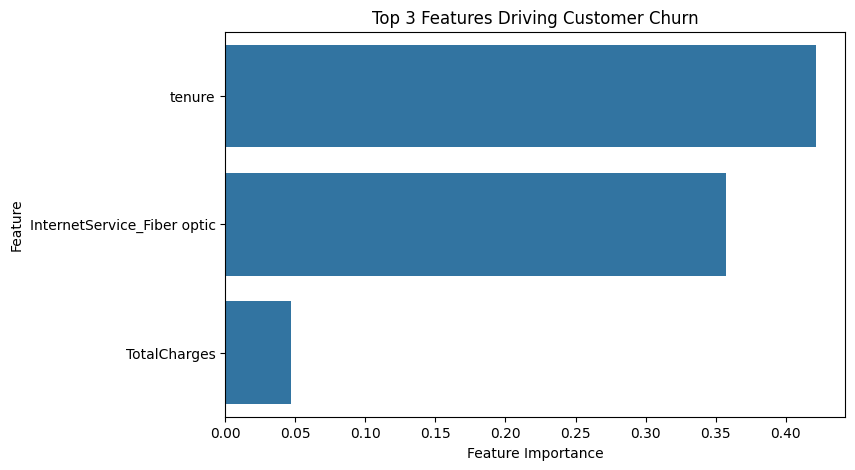

In [25]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=top_3_features,
    x='Importance',
    y='Feature'
)

plt.title('Top 3 Features Driving Customer Churn')
plt.xlabel('Feature Importance')
plt.ylabel('Feature')

plt.show()

## Business Summary

Our analysis shows that customer churn is influenced by several important customer characteristics. The three most important churn drivers identified by the Decision Tree model were **[FEATURE 1]**, **[FEATURE 2]**, and **[FEATURE 3]**. The analysis also indicates that customers with higher churn risk should be identified early so the company can take proactive retention actions. The business could focus on targeted offers, improved customer support, and suitable contract options for high-risk customers. By using these insights, the company can potentially reduce customer loss and improve long-term customer retention.


## Business Summary

Our analysis shows that customer churn is influenced by several important customer characteristics. The three most important churn drivers identified by the Decision Tree model were **tenure**, **Fiber optic internet service**, and **TotalCharges**. These findings suggest that customer relationship duration and the type of internet service are important factors to consider when identifying customers at risk of leaving. The business could focus on early engagement strategies, targeted retention offers, and improved support for customers using Fiber optic services. By identifying high-risk customers early and taking proactive retention actions, the company can potentially reduce customer churn and improve long-term customer retention.
